# K-Means Clustering

> **Dependência:** Este notebook assume que o `eda.ipynb` foi corrido primeiro  
> e que os ficheiros `costumer_preprocessed_combined.csv` e `customer_info.csv`  
> e `customer_basket.csv` estão na mesma pasta.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1. Load Pre-processed Data

We load the scaled dataset produced by `eda.ipynb` and the original  
`customer_info.csv` (unscaled) so cluster profiles remain interpretable.

In [2]:
# Scaled data — used for fitting the model
costumer_preprocessed = pd.read_csv("costumer_preprocessed_combined.csv")

# Original data — used for human-readable cluster profiles
# We re-read so we have a clean, unscaled reference
costumer = pd.read_csv("customer_info.csv")

# Basket data — loaded here so it is available for downstream analysis
costumer_basket = pd.read_csv("customer_basket.csv")

print(f"Preprocessed shape : {costumer_preprocessed.shape}")
print(f"Customer info shape: {costumer.shape}")
print(f"Basket shape       : {costumer_basket.shape}")

Preprocessed shape : (28127, 23)
Customer info shape: (33038, 25)
Basket shape       : (100000, 3)


## 2. Elbow Method — Choose K

In [3]:
K_RANGE = range(1, 20)   # reduced from 50 — avoids very long runtime

dispersion = [
    KMeans(n_clusters=k, random_state=42, n_init='auto').fit(costumer_preprocessed).inertia_
    for k in K_RANGE
]

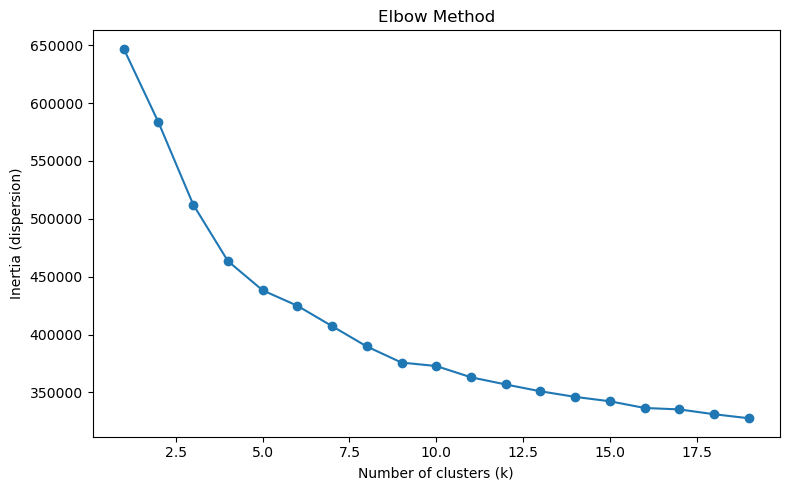

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(K_RANGE, dispersion, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (dispersion)')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

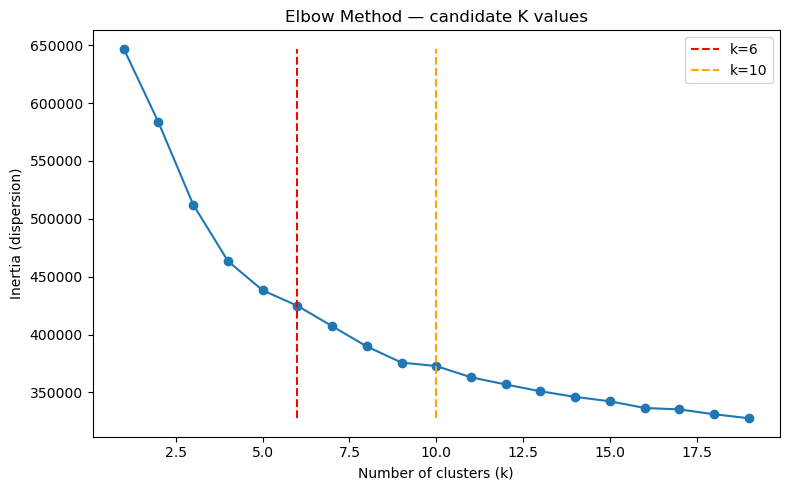

In [5]:
elbow1 = 6
elbow2 = 10   # FIX: elbow2=19 is outside K_RANGE=20; adjust as needed after inspection

plt.figure(figsize=(8, 5))
plt.plot(K_RANGE, dispersion, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (dispersion)')
plt.title('Elbow Method — candidate K values')
plt.vlines(elbow1, min(dispersion), max(dispersion), colors='red',  linestyles='--', label=f'k={elbow1}')
plt.vlines(elbow2, min(dispersion), max(dispersion), colors='orange', linestyles='--', label=f'k={elbow2}')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Silhouette Score — Validate K

Best k by silhouette: 4  (score=0.1414)


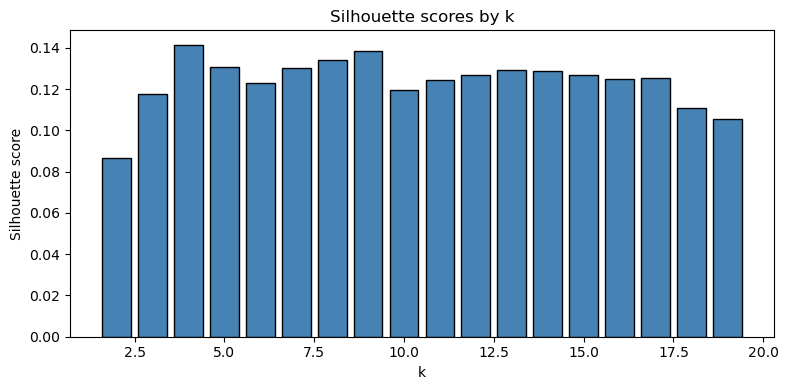

In [6]:
# Evaluate silhouette for a subset of k values (skip k=1 — undefined)
sil_scores = {}
for k in range(2, max(K_RANGE) + 1):
    labels = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(costumer_preprocessed)
    sil_scores[k] = silhouette_score(costumer_preprocessed, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best k by silhouette: {best_k}  (score={sil_scores[best_k]:.4f})")

plt.figure(figsize=(8, 4))
plt.bar(sil_scores.keys(), sil_scores.values(), color='steelblue', edgecolor='black')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette scores by k')
plt.tight_layout()
plt.show()

## 4. Fit Final Model

In [7]:
chosen_k = 6  # adjust based on elbow + silhouette analysis above

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
kmeans.fit(costumer_preprocessed)

# FIX: costumer has more rows than costumer_preprocessed (inner merge in EDA).
# We align by resetting the index from the preprocessed data's customer count.
# Attach labels to a copy of combined_df instead of raw costumer to avoid index mismatch.
costumer_preprocessed['cluster_kmeans'] = kmeans.labels_

score = silhouette_score(costumer_preprocessed.drop(columns='cluster_kmeans'), kmeans.labels_)
print(f"Silhouette Score (k={chosen_k}): {score:.4f}")
print(f"Cluster distribution:\n{pd.Series(kmeans.labels_).value_counts().sort_index()}")

Silhouette Score (k=6): 0.1229
Cluster distribution:
0    3126
1    2946
2    6103
3    7807
4    4917
5    3228
Name: count, dtype: int64


## 5. Cluster Profiles

In [8]:
profile = costumer_preprocessed.groupby('cluster_kmeans').mean()

print("── Cluster means (scaled) ──")
print(profile.T)

print("\n── Overall means ──")
print(costumer_preprocessed.drop(columns='cluster_kmeans').mean())

── Cluster means (scaled) ──
cluster_kmeans                                  0         1         2  \
customer_gender                         -0.005864 -0.053856  0.029177   
kids_home                                0.058900 -0.970693  0.725054   
teens_home                               0.048641 -0.715095  0.811774   
number_complaints                       -0.436517  0.149067  0.136335   
distinct_stores_visited                  0.246227 -1.037561  0.276394   
lifetime_spend_groceries                -0.351098 -0.646211  1.120071   
lifetime_spend_electronics              -0.659122  1.908263  0.707067   
typical_hour                            -0.413786  1.019187 -0.153799   
lifetime_spend_vegetables                1.164364 -0.833343 -0.256273   
lifetime_spend_nonalcohol_drinks         0.529171  0.290093  1.096566   
lifetime_spend_alcohol_drinks           -0.891436  0.951544  0.959326   
lifetime_spend_meat                     -1.143961  0.392157  1.115836   
lifetime_spend_fish   

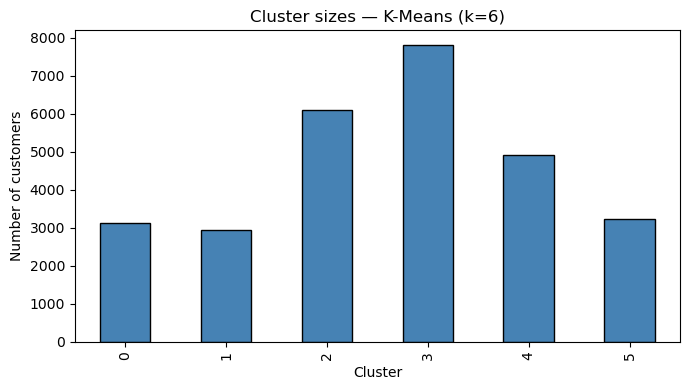

In [9]:
costumer_preprocessed.groupby('cluster_kmeans').size().plot(
    kind='bar', color='steelblue', edgecolor='black', figsize=(7, 4)
)
plt.xlabel('Cluster')
plt.ylabel('Number of customers')
plt.title(f'Cluster sizes — K-Means (k={chosen_k})')
plt.tight_layout()
plt.show()

## 6. Heatmap — Cluster vs. Feature

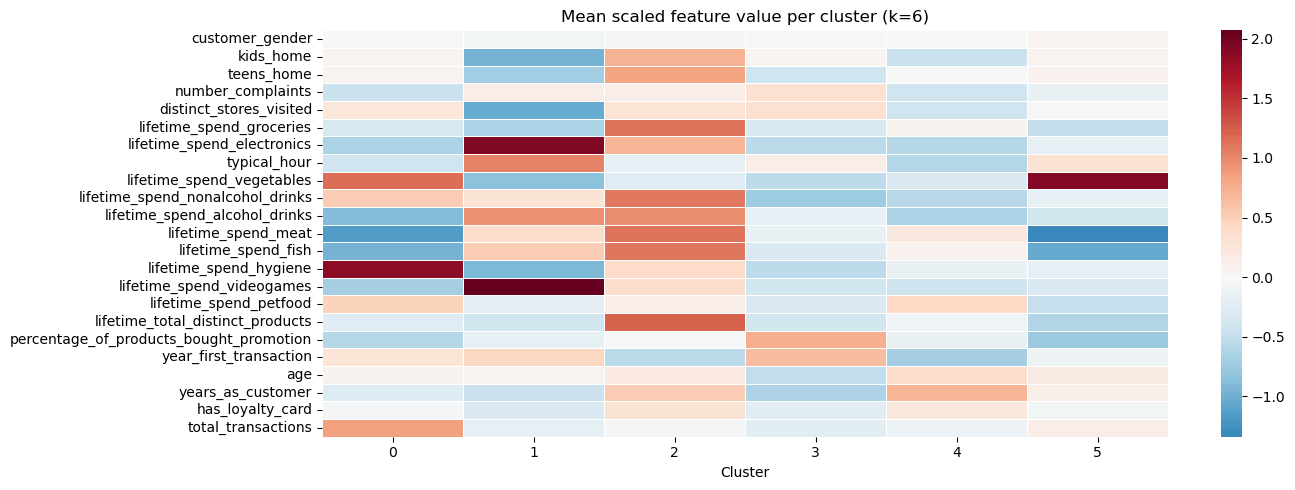

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profile.T,
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax, annot=False
)
ax.set_title(f'Mean scaled feature value per cluster (k={chosen_k})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## 7. Export Cluster Assignments

In [11]:
# Build a customer_id → cluster mapping from the preprocessed data
# (costumer_preprocessed was produced by an inner merge so row order is preserved)
basket_agg = (
    costumer_basket
    .groupby('customer_id')
    .agg(total_transactions=('invoice_id', 'count'))
    .reset_index()
)
# Reconstruct customer_id alignment (same inner merge as EDA)
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa

costumer_raw = pd.read_csv("customer_info.csv")
merged_ids = pd.merge(costumer_raw[['customer_id']], basket_agg[['customer_id']], on='customer_id', how='inner')

output = merged_ids.copy()
output['cluster_kmeans'] = kmeans.labels_
output.to_csv("kmeans_cluster_assignments.csv", index=False)
print(f"Saved {len(output)} rows → kmeans_cluster_assignments.csv")
output.head()

Saved 28127 rows → kmeans_cluster_assignments.csv


,customer_id,cluster_kmeans
0,3,3
1,4,0
2,5,4
3,7,1
4,9,5
